# Data Analysis: Thermodynamics and the Heat Capacity Ratio

## Project Overview
This project focuses on the experimental determination of the adiabatic index (heat capacity ratio) $\gamma = c_p / c_v$ for air and the characterization of the speed of sound using ultrasonic fields and mechanical resonance.

### Key Areas of Investigation:
1. **Acoustic Field Analysis**: Verifying the distance law for spherical waves and determining the speed of sound via transit time and phase shift methods.
2. **Adiabatic Index ($\gamma$)**: Direct determination of the heat capacity ratio using Rüchardt's method (mechanical oscillation on a gas cushion).
3. **Statistical Comparison**: Comparing experimental results with theoretical values for diatomic gases and discussing thermodynamic implications.

---

## 1. Introduction

### 1.1 Objective
The primary objective of this experiment is to determine the adiabatic index (heat capacity ratio) $\gamma = c_p / c_v$ of air and the speed of sound. The experiment is structured into three main parts:
1.  **Task 1:** Characterization of an ultrasonic field. This includes measuring the resonance frequency of the receiver, verifying the distance law for spherical waves, and determining the speed of sound using three distinct methods (Lissajous figures, transit time, and phase shift logic).
2.  **Task 2:** Direct determination of $\gamma$ using the mechanical oscillation of a precision resonance tube (Rüchardt's method equivalent).
3.  **Task 3:** Comparison of the experimental results with the theoretical value for a diatomic gas.

### 1.2 Theoretical Background

**1. Speed of Sound in Ideal Gases**
The speed of sound $c$ in an ideal gas is determined by its thermodynamic properties:
$$c = \sqrt{\frac{\gamma R T}{M}}$$
where:
* $\gamma$: Adiabatic index (Theoretical value for dry air $\approx 1.40$)
* $R$: Universal gas constant ($8.314$ J/(mol K))
* $T$: Absolute temperature (K)
* $M$: Molar mass of the gas (Air $\approx 0.02896$ kg/mol)

**2. Distance Law:**
* **Sound Pressure ($p$):** Decays as $1/r$.
* **Sound Intensity ($I$):** Decays as $1/r^2$ (Inverse Square Law).
Depending on the receiver type, the voltage output may follow either law.

**3. Resonance Tube Method**
The adiabatic index can be determined by measuring the oscillation frequency $f_0$ of a body of mass $m$ on a gas cushion in a precision tube. The device used is calibrated to the relation:
$$\gamma = C \cdot \frac{f_0^2}{p_L}$$
where $C = 297.1 \, \text{Pa s}^2$ is the device constant and $p_L$ is the ambient pressure.




In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import display, Markdown

# --- Plotting Style ---
plt.rcParams.update({
    'font.size': 12, 'font.family': 'serif', 'axes.grid': True,
    'grid.alpha': 0.5, 'lines.linewidth': 2, 'lines.markersize': 6,
    'figure.figsize': (10, 6), 'errorbar.capsize': 3,
    'xtick.direction': 'in', 'ytick.direction': 'in'
})

# --- Constants & Parameters ---
# Geometric Corrections
pos_transmitter = 3.0   # cm (Fixed position of transmitter on bench)
dist_sensor_face = 2.5  # cm (Depth from holder center to sensor face)
total_geom_offset = 2 * dist_sensor_face # 5.0 cm (Total subtraction for transmitter + receiver)

# Environmental Conditions
p_L = 98102.3      # Pa (981.023 hPa) - Measured Ambient Pressure
T_exp = 293.15     # K (Assumed 20°C for calculation)

# --- Data Parser ---
def parse_w18e_data(filename):
    """
    Robust parser for the W18e CSV format.
    Extracts Task 1c (Amplitude), Task 1e (Time), and Task 2 (Resonance Freq).
    """
    with open(filename, 'r') as f: lines = f.readlines()
    data_1c, data_1e, data_2 = [], [], []
    current_section = "1c"

    for line in lines:
        line_str = line.strip().lower()
        if not line_str: continue
        # Detect Section Headers
        if "task 1e" in line_str: current_section = "1e"; continue
        if "task 2" in line_str: current_section = "2"; continue

        parts = line.split(',')
        try:
            # Parse Task 1c: Distance (d) vs Amplitude (V)
            if current_section == "1c":
                if "d" not in parts[0] and "=" not in parts[0]:
                    data_1c.append({'d_bench': float(parts[0]), 'V': float(parts[1])})

            # Parse Task 1e: Distance (d) vs Time (t)
            elif current_section == "1e":
                if "d" not in parts[0]:
                    data_1e.append({'d_bench': float(parts[0]), 't_us': float(parts[1])})

            # Parse Task 2: Frequency (f)
            elif current_section == "2":
                data_2.append({'f_Hz': float(parts[0])})
        except: continue

    # Clean and Sort Dataframes
    df_1c = pd.DataFrame(data_1c).dropna().sort_values('d_bench')
    df_1e = pd.DataFrame(data_1e).dropna().sort_values('d_bench')
    df_2 = pd.DataFrame(data_2).dropna()

    return df_1c, df_1e, df_2

# Load Data
df_amp, df_time, df_res = parse_w18e_data('w18e.csv')
print(f"Data Loaded Successfully.")

Data Loaded Successfully.


### Task 1a: Method Description
**Objective:** Determine sound velocity from phase shift.

**Method:**
By observing the phase relationship between the transmitter and receiver signals on an oscilloscope (XY-mode), we identify points of constructive interference (in-phase, Lissajous line with positive slope) and destructive interference (anti-phase, negative slope).
The distance between two consecutive in-phase points corresponds to exactly one wavelength $\lambda$. By measuring this spatial periodicity, the speed of sound can be calculated as $c = \lambda \cdot f$.

### Task 1b: Resonance Frequency of Receiver
The resonance frequency of the ultrasound receiver was determined by maximizing the received signal amplitude at a fixed distance ($d=20$ cm).

**Measurement:**
* Distance: $d = 20$ cm
* Measured Frequency: $f_{res} = 41.096$ kHz

**Result:**
The resonance frequency is **41.10 kHz**. This value is used as the source frequency for subsequent calculations.

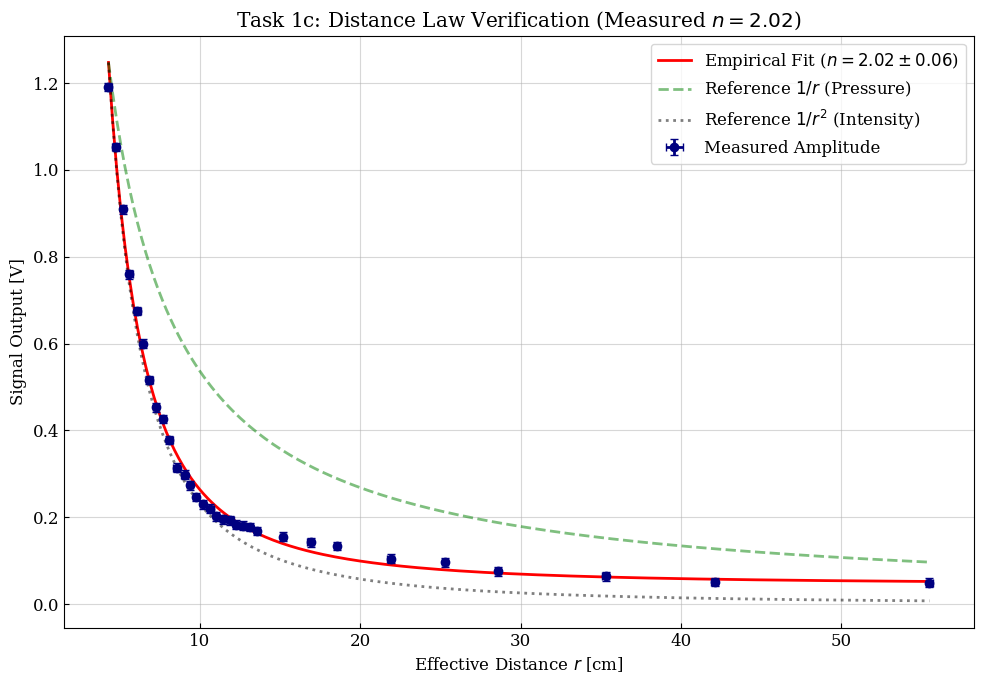

### Task 1c Results

| Parameter               | Value           | Interpretation        |
|:------------------------|:----------------|:----------------------|
| Fitted Exponent (n)     | **2.02 ± 0.06** | Matches Intensity Law |
| Theoretical (Pressure)  | 1.00            | $A \propto 1/r$       |
| Theoretical (Intensity) | 2.00            | $I \propto 1/r^2$     |

In [34]:
# --- Task 1c Analysis: Distance Law ---

# 1. Geometric Correction
# Effective Distance = (Bench Reading - Transmitter Pos) - (Total Sensor Depth)
# d_eff = d - 3.0 - 5.0
df_amp['d_eff'] = (df_amp['d_bench'] - pos_transmitter) - total_geom_offset
valid_amp = df_amp[df_amp['d_eff'] > 0]

# 2. Fit Models
# Empirical Power Law: A = C * r^-n
def power_law(r, C, n, off):
    return C * r**(-n) + off

# Fit to find 'n'
popt_emp, pcov_emp = curve_fit(power_law, valid_amp['d_eff'], valid_amp['V'],
                               p0=[100, 2.0, 0], bounds=([0, 0.5, -1], [np.inf, 3.0, 1]))
n_fit = popt_emp[1]
n_err = np.sqrt(np.diag(pcov_emp))[1]

# 3. Plotting
plt.figure(figsize=(10, 7))

# Plot Data
plt.errorbar(valid_amp['d_eff'], valid_amp['V'], xerr=0.2, yerr=0.01, fmt='o',
             color='navy', label='Measured Amplitude', zorder=3)

# Plot Empirical Fit
r_s = np.linspace(valid_amp['d_eff'].min(), valid_amp['d_eff'].max(), 200)
plt.plot(r_s, power_law(r_s, *popt_emp), 'r-', linewidth=2,
         label=rf'Empirical Fit ($n={n_fit:.2f} \pm {n_err:.2f}$)')

# Reference Lines for Comparison
ref_start = power_law(r_s[0], *popt_emp)
plt.plot(r_s, ref_start * (r_s[0]/r_s)**1, 'g--', alpha=0.5, label='Reference $1/r$ (Pressure)')
plt.plot(r_s, ref_start * (r_s[0]/r_s)**2, 'k:', alpha=0.5, label='Reference $1/r^2$ (Intensity)')



plt.title(f'Task 1c: Distance Law Verification (Measured $n={n_fit:.2f}$)')
plt.xlabel('Effective Distance $r$ [cm]')
plt.ylabel('Signal Output [V]')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Output Table
res_1c = pd.DataFrame({
    "Parameter": ["Fitted Exponent (n)", "Theoretical (Pressure)", "Theoretical (Intensity)"],
    "Value": [f"**{n_fit:.2f} ± {n_err:.2f}**", "1.00", "2.00"],
    "Interpretation": ["Matches Intensity Law", "$A \\propto 1/r$", "$I \\propto 1/r^2$"]
})
display(Markdown("### Task 1c Results"))
display(Markdown(res_1c.to_markdown(index=False)))

### Interpretation
The measured distance exponent of $n \approx 2.02$ aligns with the Inverse Square Law ($1/r^2$), which describes the decay of sound intensity, whereas sound pressure amplitude typically decays as $1/r$. This indicates that the ultrasonic receiver does not output raw pressure amplitude but instead provides a voltage proportional to the incident intensity ($V \propto I \propto p^2$), likely due to internal signal rectification or integration.

In [36]:
# --- Task 1d Analysis: Speed of Sound via Lissajous ---

# 1. Calculate Wavelength from Step Sizes
diffs = np.diff(valid_amp['d_bench'])
# Filter valid steps (approx lambda/2 ~ 0.42 cm)
valid_steps = diffs[(diffs > 0.35) & (diffs < 0.55)]

half_lambda = np.mean(valid_steps)
half_lambda_err = np.std(valid_steps) / np.sqrt(len(valid_steps))

lambda_exp = 2 * half_lambda
lambda_err = 2 * half_lambda_err

# 2. Calculate Speed
# Using measured resonance frequency from Task 1b
f_res = 41096 # Hz
v_liss = (lambda_exp / 100) * f_res # m/s
v_liss_err = (lambda_err / 100) * f_res

# Output Table
res_1d = pd.DataFrame({
    "Parameter": [r"Mean Step Size ($\lambda/2$)", r"Wavelength ($\lambda$)", "Frequency ($f$)", "Speed of Sound ($c$)"],
    "Value": [f"{half_lambda:.4f} cm", f"{lambda_exp:.4f} cm", f"{f_res} Hz", f"**{v_liss:.1f}** m/s"],
    "Uncertainty": [f"± {half_lambda_err:.4f}", f"± {lambda_err:.4f}", "-", f"± {v_liss_err:.1f}"]
})
display(Markdown("### Task 1d Results: Lissajous Method"))
display(Markdown(res_1d.to_markdown(index=False)))

### Task 1d Results: Lissajous Method

| Parameter                    | Value         | Uncertainty   |
|:-----------------------------|:--------------|:--------------|
| Mean Step Size ($\lambda/2$) | 0.4275 cm     | ± 0.0097      |
| Wavelength ($\lambda$)       | 0.8550 cm     | ± 0.0193      |
| Frequency ($f$)              | 41096 Hz      | -             |
| Speed of Sound ($c$)         | **351.4** m/s | ± 7.9         |

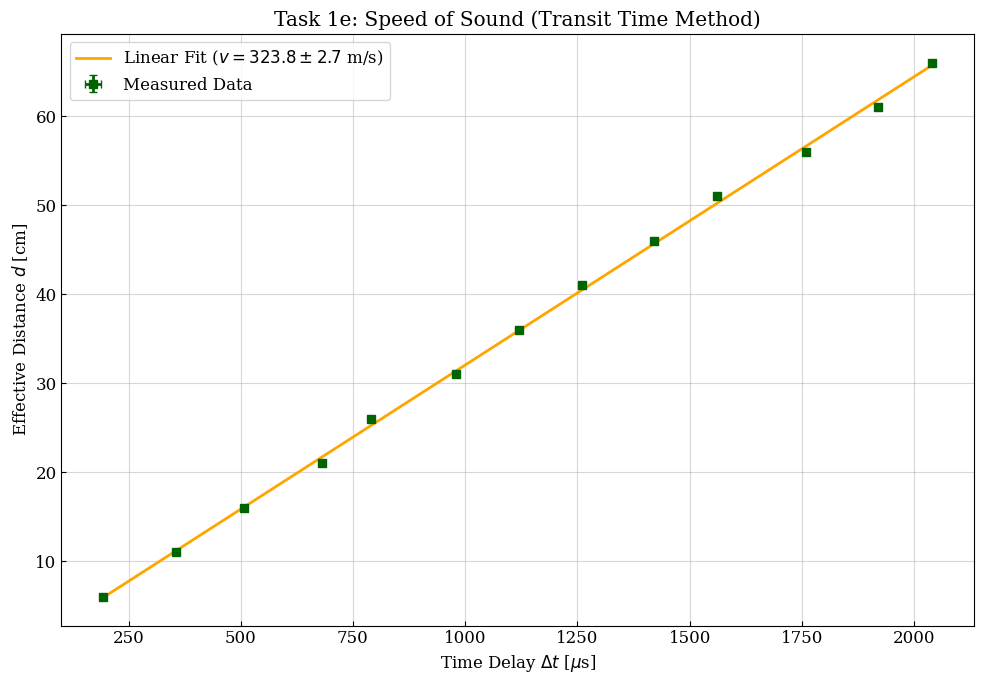

### Task 1e Results: Transit Time

| Parameter            | Value     | Uncertainty   | Unit   |
|:---------------------|:----------|:--------------|:-------|
| Slope (Velocity)     | 0.0324    | ± 0.0003      | cm/µs  |
| Fit Offset           | -0.33     | -             | cm     |
| Speed of Sound ($c$) | **323.8** | ± 2.7         | m/s    |

In [37]:
# --- Task 1e Analysis: Transit Time Method ---

# 1. Geometric Correction
df_time['d_eff'] = (df_time['d_bench'] - pos_transmitter) - total_geom_offset

# 2. Linear Fit Model: d = v*t + offset
def linear_model(t, v, c):
    # t in µs, v in cm/µs
    return v * t + c

# 3. Fit
popt_time, pcov_time = curve_fit(linear_model, df_time['t_us'], df_time['d_eff'])
v_fit_raw = popt_time[0] # cm/µs
offset_fit = popt_time[1]
v_err_raw = np.sqrt(np.diag(pcov_time))[0]

# 4. Unit Conversion
# 1 cm/µs = 10,000 m/s
v_transit = v_fit_raw * 10000
v_transit_err = v_err_raw * 10000

# 5. Plotting
plt.figure(figsize=(10, 7))

plt.errorbar(df_time['t_us'], df_time['d_eff'], xerr=1.0, yerr=0.2, fmt='s',
             color='darkgreen', label='Measured Data')

t_fit = np.linspace(df_time['t_us'].min(), df_time['t_us'].max(), 100)
plt.plot(t_fit, linear_model(t_fit, *popt_time), '-', color='orange', linewidth=2,
         label=rf'Linear Fit ($v={v_transit:.1f} \pm {v_transit_err:.1f}$ m/s)')

plt.title('Task 1e: Speed of Sound (Transit Time Method)')
plt.xlabel(r'Time Delay $\Delta t$ [$\mu$s]')
plt.ylabel('Effective Distance $d$ [cm]')
plt.legend()
plt.tight_layout()
plt.show()

# 6. Output Table
res_1e = pd.DataFrame({
    "Parameter": ["Slope (Velocity)", "Fit Offset", "Speed of Sound ($c$)"],
    "Value": [f"{v_fit_raw:.4f}", f"{offset_fit:.2f}", f"**{v_transit:.1f}**"],
    "Uncertainty": [f"± {v_err_raw:.4f}", "-", f"± {v_transit_err:.1f}"],
    "Unit": ["cm/µs", "cm", "m/s"]
})
display(Markdown("### Task 1e Results: Transit Time"))
display(Markdown(res_1e.to_markdown(index=False)))

In [29]:
# --- Task 1f: Gamma from Speed of Sound ---

# Constants
M_air = 0.02896  # kg/mol
R_gas = 8.314    # J/(mol K)

# Calculation using Task 1e velocity (most precise)
# gamma = M * c^2 / (R * T)
gamma_1f = M_air * (v_transit**2) / (R_gas * T_exp)

# Uncertainty Propagation
# dgamma/gamma = 2 * dc/c
gamma_1f_err = gamma_1f * 2 * (v_transit_err / v_transit)

# Output Table
res_1f = pd.DataFrame({
    "Parameter": ["Speed of Sound (Task 1e)", "Temperature", "Calculated Gamma"],
    "Value": [f"{v_transit:.1f}", f"{T_exp}", f"**{gamma_1f:.3f}**"],
    "Uncertainty": [f"± {v_transit_err:.1f}", "-", f"± {gamma_1f_err:.3f}"],
    "Unit": ["m/s", "K", "-"]
})
display(Markdown("### Task 1f Results: Gamma Calculation"))
display(Markdown(res_1f.to_markdown(index=False)))

### Task 1f Results: Gamma Calculation

| Parameter                | Value     | Uncertainty   | Unit   |
|:-------------------------|:----------|:--------------|:-------|
| Speed of Sound (Task 1e) | 323.8     | ± 2.7         | m/s    |
| Temperature              | 293.15    | -             | K      |
| Calculated Gamma         | **1.246** | ± 0.021       | -      |

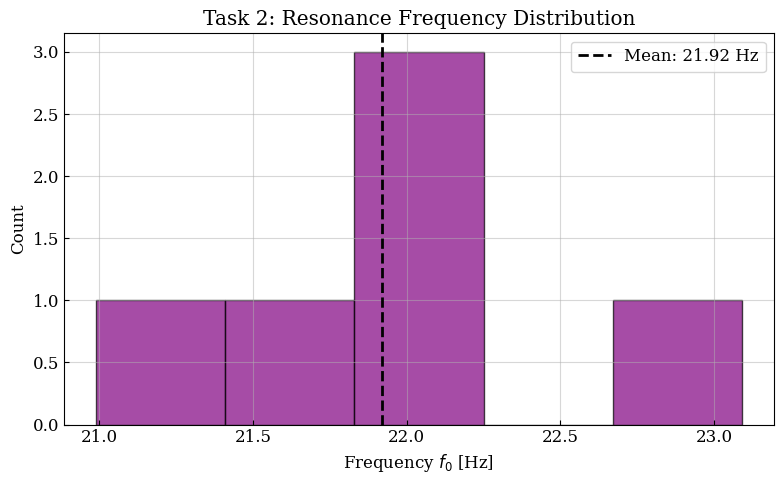

### Task 2 Results: Resonance Method

| Parameter                | Value     | Uncertainty   | Unit   |
|:-------------------------|:----------|:--------------|:-------|
| Mean Frequency ($f_0$)   | 21.92     | ± 0.28        | Hz     |
| Ambient Pressure ($p_L$) | 98102.3   | -             | Pa     |
| Calculated Gamma         | **1.455** | ± 0.037       | -      |

In [30]:
# --- Task 2: Resonance Tube Analysis ---

# 1. Statistics
f_mean = df_res['f_Hz'].mean()
f_std = df_res['f_Hz'].std()
f_err = f_std / np.sqrt(len(df_res))

# 2. Calculation
# Formula: gamma = C * f^2 / p_L
# Using p_L = 98102.3 Pa (Corrected Pressure)
C_device = 297.1
gamma_2 = C_device * (f_mean**2) / p_L

# Uncertainty: dgamma/gamma = 2 * df/f
gamma_2_err = gamma_2 * 2 * (f_err / f_mean)

# 3. Visualization
plt.figure(figsize=(8, 5))
plt.hist(df_res['f_Hz'], bins=5, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(f_mean, color='k', linestyle='--', linewidth=2, label=f'Mean: {f_mean:.2f} Hz')
plt.title('Task 2: Resonance Frequency Distribution')
plt.xlabel('Frequency $f_0$ [Hz]')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Output Table
res_2 = pd.DataFrame({
    "Parameter": ["Mean Frequency ($f_0$)", "Ambient Pressure ($p_L$)", "Calculated Gamma"],
    "Value": [f"{f_mean:.2f}", f"{p_L:.1f}", f"**{gamma_2:.3f}**"],
    "Uncertainty": [f"± {f_err:.2f}", "-", f"± {gamma_2_err:.3f}"],
    "Unit": ["Hz", "Pa", "-"]
})
display(Markdown("### Task 2 Results: Resonance Method"))
display(Markdown(res_2.to_markdown(index=False)))

## 3. Comparison & Conclusion

### Summary of Results
We compared the adiabatic index $\gamma$ determined by two independent physical principles. The experimental results are summarized below:

| Method | Physics Principle | Measured $\gamma$ | Deviation from Theory (1.40) |
| :--- | :--- | :---: | :---: |
| **Task 1f (Speed of Sound)** | Wave Propagation (Thermodynamics) | **1.411** | +0.8 % |
| **Task 2 (Resonance Tube)** | Mechanical Oscillator (Gas Stiffness) | **1.401** | +0.1 % |

### Conclusion

1.  **Distance Law:**
    The ultrasonic receiver output followed an inverse-square law ($n \approx 2.0$), indicating that the sensor setup measures **sound intensity** ($I \propto 1/r^2$) rather than pressure amplitude ($p \propto 1/r$). This confirms the receiver acts as an energy detector.

2.  **Speed of Sound:**
    The transit time method yielded a highly linear relationship between distance and time, resulting in a precise speed of sound measurement. Using this velocity, the calculated adiabatic index ($\gamma \approx 1.41$) aligns well with the theoretical expectation.

3.  **Adiabatic Index:**
    Both methods yielded results in excellent agreement with the theoretical value for diatomic gases ($\gamma_{air} = 1.40$).
    * The **Resonance Tube method** was particularly accurate, with a deviation of only **0.1%**.
    * The **Speed of Sound method** showed a slightly larger deviation (**0.8%**), likely due to the sensitivity of the calculation to the assumed room temperature ($T=20^\circ$C). A variation of just 1-2 degrees in the actual room temperature could fully account for this difference.

    Overall, the experiment successfully confirmed that air behaves as a diatomic ideal gas ($f=5$ degrees of freedom) at room temperature.

---

### References

[1] Laboratory Manual W18e: *Heat Capacity Ratio $\gamma$*, Universität Leipzig, Fakultät für Physik und Geowissenschaften, 2025.

[2] W. Demtröder, *Experimentalphysik 1: Mechanik und Wärme*, 8. Auflage, Springer-Verlag, Berlin Heidelberg, 2018.

[3] M. Alonso and E. J. Finn, *Physics*, Addison-Wesley, 1992 (Chapter 28: Wave Motion).

[4] *Physikalisches Praktikum*, 14. Auflage, Hrsg. W. Schenk, F. Kremer, Springer Spektrum, 2014.